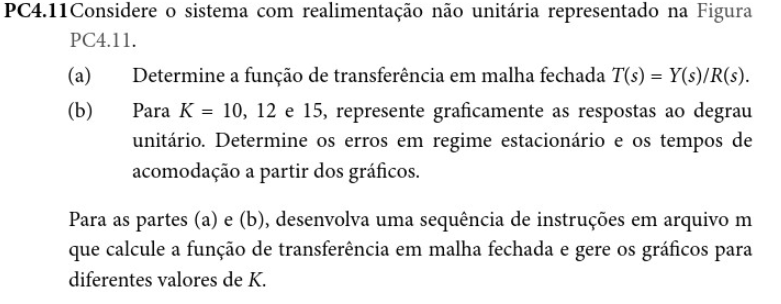
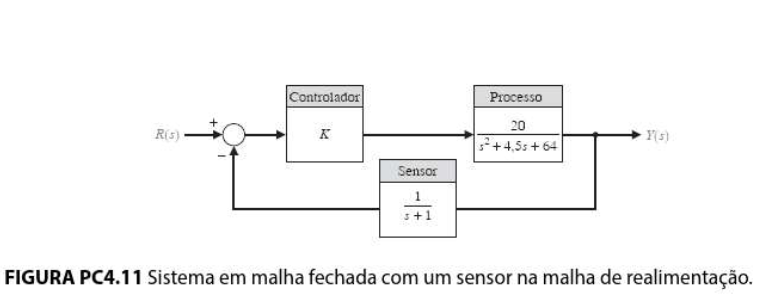

--- Análise do Sistema PC4.11 ---

Para K = 10:
  T(s) Numerador: [200. 200.]
  T(s) Denominador: [  1.    5.5  68.5 264. ]
  Erro em regime (ess): 0.2424
  Tempo de acomodação (ts): 7.9557 s

Para K = 12:
  T(s) Numerador: [240. 240.]
  T(s) Denominador: [  1.    5.5  68.5 304. ]
  Erro em regime (ess): 0.2105
  Tempo de acomodação (ts): 13.2876 s

Para K = 15:
  T(s) Numerador: [300. 300.]
  T(s) Denominador: [  1.    5.5  68.5 364. ]
  Erro em regime (ess): 0.1758
  Tempo de acomodação (ts): 82.7674 s


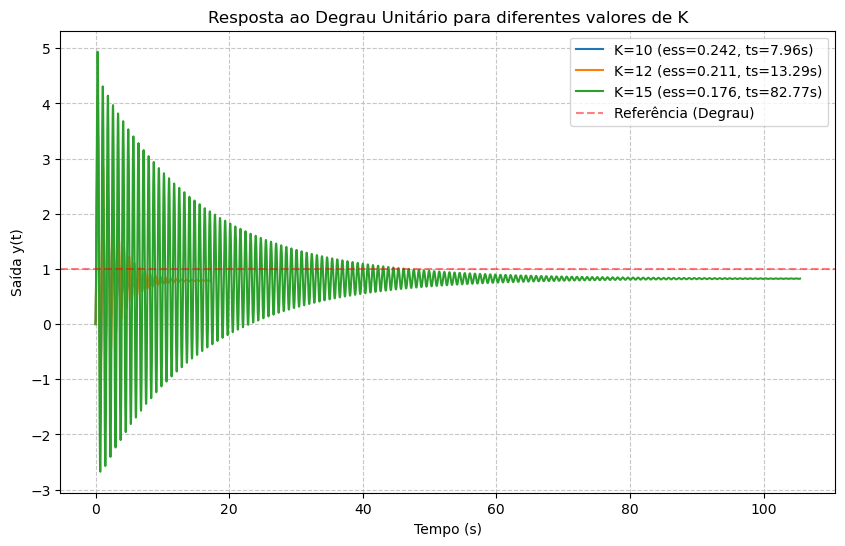

In [1]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# 1. Definição da variável de Laplace 's'
s = ct.tf('s')

# 2. Definição dos blocos do sistema
G = 20 / (s**2 + 4.5*s + 64)  # Processo
H = 1 / (s + 1)               # Sensor

K_values = [10, 12, 15]
plt.figure(figsize=(10, 6))

print("--- Análise do Sistema PC4.11 ---")

for K in K_values:
    # Malha direta: Controlador * Processo
    L = K * G
    
    # Malha fechada: T = L / (1 + L*H)
    T = ct.feedback(L, H)
    
    # Resposta ao degrau unitário
    t, y = ct.step_response(T)
    
    # Obtenção de métricas (tempo de acomodação, etc.)
    info = ct.step_info(T)
    ts = info['SettlingTime']
    
    # Erro em regime estacionário (ess = 1 - valor_final_da_saída)
    y_final = ct.dcgain(T)
    ess = 1 - y_final
    
    # Plotagem
    label_str = f'K={K} (ess={ess:.3f}, ts={ts:.2f}s)'
    plt.plot(t, y, label=label_str)
    
    print(f"\nPara K = {K}:")
    print(f"  T(s) Numerador: {T.num[0][0]}")
    print(f"  T(s) Denominador: {T.den[0][0]}")
    print(f"  Erro em regime (ess): {ess:.4f}")
    print(f"  Tempo de acomodação (ts): {ts:.4f} s")

# Configurações do gráfico
plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Referência (Degrau)')
plt.title('Resposta ao Degrau Unitário para diferentes valores de K')
plt.xlabel('Tempo (s)')
plt.ylabel('Saída y(t)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()